# Solution: Exercise 01

## 📚 Instructor Solution

This notebook contains the complete solution to the exercise.

**Grading Notes:**
- Review student solutions against this reference
- Check for correct logic and implementation
- Verify code quality and documentation


# Unit 1 - Exercise 1: Data Science Fundamentals Practice
## تمرين 1: ممارسة أساسيات علم البيانات

### Instructions:
1. Load a sample dataset (provided below)
2. Explore the data using pandas operations
3. Perform basic statistical analysis
4. Create visualizations
5. Compare CPU (pandas) operations (optional: compare with cuDF if available)

**Dataset:** Student performance data


## 📥 Inputs & 📤 Outputs | المدخلات والمخرجات

**Inputs:**
- Sample dataset: student performance (100 rows, 9 columns), created in notebook
- Libraries: pandas, numpy, matplotlib, seaborn

**Outputs:** (per task)
- Task 1: First 5 rows, shape, info, descriptive statistics
- Task 2–5: Aggregations, filters, visualizations, optional CPU/cuDF comparison

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for better display
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")


## Sample Dataset - Student Performance Data
### البيانات النموذجية - بيانات أداء الطلاب


In [2]:
np.random.seed(42)
data = {
    'student_id': range(1, 101),
    'student_name': [f'Student_{i}' for i in range(1, 101)],
    'age': np.random.randint(18, 25, 100),
    'math_score': np.random.uniform(50, 100, 100),
    'science_score': np.random.uniform(50, 100, 100),
    'english_score': np.random.uniform(50, 100, 100),
    'attendance': np.random.uniform(60, 100, 100),
    'study_hours': np.random.uniform(5, 40, 100),
    'department': np.random.choice(['CS', 'Engineering', 'Business', 'Arts', 'Science'], 100)
}

df = pd.DataFrame(data)


## Task 1: Explore the data
### المهمة 1: استكشاف البيانات

**Instructions:**
- Display first 5 rows
- Display data shape
- Display data info
- Display descriptive statistics


In [3]:
print("=" * 60)
print("Task 1: Explore the data")
print("=" * 60)
print(df.head())
print("\nShape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescriptive statistics:")
print(df.describe())

Task 1: Explore the data
   student_id student_name  age  math_score  science_score  english_score  \
0           1    Student_1   24   54.424625      83.606777      96.807739   
1           2    Student_2   21   59.799143      88.080981      84.801490   
2           3    Student_3   22   52.261364      61.881877      78.503059   
3           4    Student_4   24   66.266517      86.410817      54.858825   
4           5    Student_5   20   69.433864      68.389157      80.750361   

   attendance  study_hours   department  
0   61.060452     5.397378      Science  
1   83.431023    21.403122      Science  
2   97.609210     6.970615  Engineering  
3   83.018967     9.158627     Business  
4   75.526797     9.113419     Business  

Shape: (100, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   student_id     100 non-null    int64  
 

## Task 2: Statistical Analysis
### المهمة 2: التحليل الإحصائي

**Instructions:**
- Calculate mean, median, std for each score column
- Find correlation between scores
- Calculate average scores by department


In [4]:
print("\n" + "=" * 60)
print("Task 2: Statistical Analysis")
print("=" * 60)
score_cols = ['math_score', 'science_score', 'english_score']
for c in score_cols:
    print(f"{c}: mean={df[c].mean():.2f}, median={df[c].median():.2f}, std={df[c].std():.2f}")
print("\nCorrelation (scores):")
print(df[score_cols].corr())
print("\nAvg scores by department:")
print(df.groupby('department')[score_cols].mean())


Task 2: Statistical Analysis
math_score: mean=73.27, median=71.11, std=14.81
science_score: mean=75.62, median=77.80, std=14.64
english_score: mean=74.57, median=76.01, std=14.05

Correlation (scores):
               math_score  science_score  english_score
math_score       1.000000      -0.042731      -0.039800
science_score   -0.042731       1.000000      -0.215176
english_score   -0.039800      -0.215176       1.000000

Avg scores by department:
             math_score  science_score  english_score
department                                           
Arts          70.414248      85.049876      72.150464
Business      71.416958      75.159011      71.829139
CS            77.685702      73.621773      74.719878
Engineering   75.105191      73.274577      74.952155
Science       71.465187      74.189398      78.928089


## Task 3: Data Filtering
### المهمة 3: تصفية البيانات

**Instructions:**
- Filter students with math_score > 80
- Select students from 'CS' department
- Find students with attendance > 90


In [5]:
print("\n" + "=" * 60)
print("Task 3: Data Filtering")
print("=" * 60)
math_80 = df[df['math_score'] > 80]
print(f"Math > 80: {len(math_80)} students")
cs = df[df['department'] == 'CS']
print(f"CS department: {len(cs)} students")
att_90 = df[df['attendance'] > 90]
print(f"Attendance > 90: {len(att_90)} students")


Task 3: Data Filtering
Math > 80: 36 students
CS department: 17 students
Attendance > 90: 35 students


## Task 4: Create Visualizations
### المهمة 4: إنشاء التصورات

**Instructions:**
- Create a histogram of math scores
- Create a scatter plot: study_hours vs math_score
- Create a bar chart: average score by department
- Create a correlation heatmap



Task 4: Create Visualizations


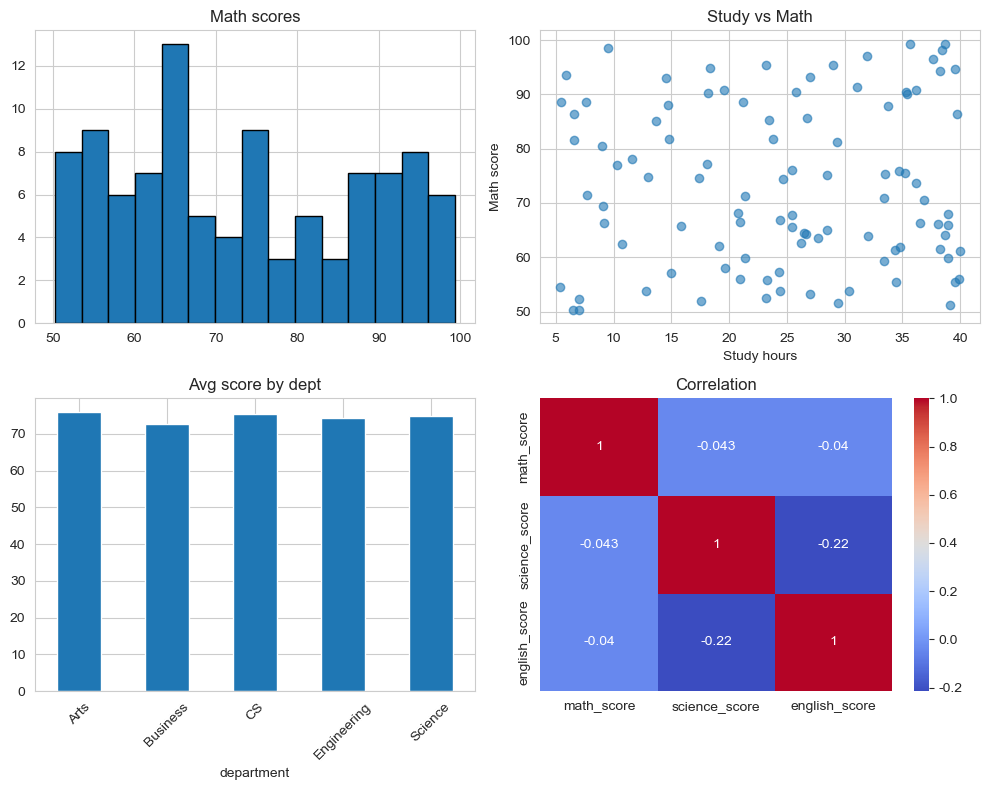

In [6]:
print("\n" + "=" * 60)
print("Task 4: Create Visualizations")
print("=" * 60)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
df['math_score'].hist(ax=axes[0,0], bins=15, edgecolor='black'); axes[0,0].set_title('Math scores')
axes[0,1].scatter(df['study_hours'], df['math_score'], alpha=0.6); axes[0,1].set_xlabel('Study hours'); axes[0,1].set_ylabel('Math score'); axes[0,1].set_title('Study vs Math')
df.groupby('department')[score_cols].mean().mean(axis=1).plot(kind='bar', ax=axes[1,0]); axes[1,0].set_title('Avg score by dept'); axes[1,0].tick_params(axis='x', rotation=45)
sns.heatmap(df[score_cols].corr(), annot=True, ax=axes[1,1], cmap='coolwarm'); axes[1,1].set_title('Correlation')
plt.tight_layout()
plt.show()

## Task 5: Data Aggregation
### المهمة 5: تجميع البيانات

**Instructions:**
- Group by department and calculate mean scores
- Find department with highest average math score
- Calculate total study hours per department


In [7]:
print("\n" + "=" * 60)
print("Task 5: Data Aggregation")
print("=" * 60)
by_dept = df.groupby('department')[score_cols].mean()
print("Mean scores by department:")
print(by_dept)
best_math = df.groupby('department')['math_score'].mean().idxmax()
print(f"\nDept with highest avg math: {best_math}")
study_by_dept = df.groupby('department')['study_hours'].sum()
print("\nTotal study hours per department:")
print(study_by_dept)
print("\n" + "=" * 60)
print("Exercise 1 Complete!")
print("اكتمل التمرين 1!")
print("=" * 60)


Task 5: Data Aggregation
Mean scores by department:
             math_score  science_score  english_score
department                                           
Arts          70.414248      85.049876      72.150464
Business      71.416958      75.159011      71.829139
CS            77.685702      73.621773      74.719878
Engineering   75.105191      73.274577      74.952155
Science       71.465187      74.189398      78.928089

Dept with highest avg math: CS

Total study hours per department:
department
Arts           363.440426
Business       581.786454
CS             438.620481
Engineering    631.801999
Science        465.553522
Name: study_hours, dtype: float64

Exercise 1 Complete!
اكتمل التمرين 1!


---

## Teaching Notes

**Common Mistakes:**
- Using `df.describe()` without `print()` for consistency with other outputs
- Forgetting to filter before `len()` when counting (e.g. `df[df['math_score'] > 80]`)
- Mixing up `groupby().mean()` vs `groupby().agg()`; heatmap without `annot=True`

**Key Concepts:**
- Exploration: `head`, `shape`, `info`, `describe`
- Filtering: boolean indexing, `df[df['col'] > x]`
- Aggregation: `groupby`, `corr`; visualization: `hist`, `scatter`, `heatmap`
